# Mock Yorum Verisi — Keşifsel Veri Analizi (EDA)

**Amaç:** `mock_comments.json` üzerinde etkileşim dağılımları, zaman desenleri ve yorum uzunluklarını incelemek.

**DoD:** Bulgular bu notebook sonundaki özet bölümünde ekip ile paylaşılabilir durumda olmalıdır.

| Bölüm | İçerik |
|-------|--------|
| 1 | Veri yükleme ve ön işleme |
| 2 | Etkileşim dağılımları |
| 3 | Saat / gün desenleri |
| 4 | Yorum uzunlukları |
| 5 | Veri kalitesi kontrolleri |
| 6 | Bulguların özeti |

In [57]:
import json
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

warnings.filterwarnings("ignore")

plt.style.use("seaborn-v0_8-whitegrid")
sns.set_theme(style="whitegrid", palette="muted", font_scale=1.05)
plt.rcParams.update({
    "figure.figsize": (10, 5),
    "figure.dpi": 100,
    "axes.titlesize": 13,
    "axes.labelsize": 11,
})

DATA_PATH = Path("../src/mock_comments.json")
DAY_ORDER = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]
DAY_LABELS_TR = {
    "Monday": "Pzt", "Tuesday": "Sal", "Wednesday": "Çar",
    "Thursday": "Per", "Friday": "Cum", "Saturday": "Cmt", "Sunday": "Paz",
}

## 1. Veri Yükleme ve Ön İşleme

In [ ]:
with open(DATA_PATH, "r", encoding="utf-8") as f:
    raw_data = json.load(f)

df = pd.DataFrame(raw_data)

df["commentedAt"] = pd.to_datetime(df["commentedAt"])
df["hour"] = df["commentedAt"].dt.hour
df["day_of_week"] = pd.Categorical(
    df["commentedAt"].dt.day_name(), categories=DAY_ORDER, ordered=True
)
df["date"] = df["commentedAt"].dt.date
df["text_length"] = df["text"].str.len()
df["word_count"] = df["text"].str.split().str.len()
df["has_hashtag"] = df["text"].str.contains(r"#\w+", regex=True)
df["has_mention"] = df["text"].str.contains(r"@\w+", regex=True)

print(f"Toplam yorum: {len(df):,}")
print(f"Tarih aralığı: {df['commentedAt'].min().date()} → {df['commentedAt'].max().date()}")
print(f"Benzersiz post: {df['postId'].nunique():,} | Benzersiz yazar: {df['authorHash'].nunique():,}")
df.head()

Toplam yorum: 2,500
Tarih aralığı: 2026-01-22 → 2026-07-22
Benzersiz post: 100 | Benzersiz yazar: 300


,comment_id,post_id,post_type,account_id,author_hash,text,created_at,likes_count,language,mock_category,hour,day_of_week,date,text_length,word_count,has_hashtag,has_mention
0,e093edf6-4dbb-4458-8160-c071152dd9a6,84,lifestyle,4,8df56d8a2f70b68e79f690eab14fde159377c4f91f80f0...,🙌🏼🙌🏼 @akdenizturgut,2026-02-14 21:24:58.968309,0,tr,emoji,21,Saturday,2026-02-14,19,2,False,True
1,6a207b10-4acb-446d-aaa2-16874cc317e1,11,fashion,1,e39294760246877edca2f76a932b77e0f9affdf0b2098c...,Aradigim kombin tam olarak buydu,2026-07-11 07:13:18.300252,1,tr,positive,7,Saturday,2026-07-11,32,5,False,False
2,05549028-cf5a-46ee-8cd0-217a16b49f61,63,food,3,69bf350c2cece9211b610184201fb5a1cc1e5359e9e8ac...,GÖRDÜĞÜM EN GERÇEKTEN IYI PAYLAŞIM OLABILIR,2026-03-09 23:07:14.761222,138,tr,positive,23,Monday,2026-03-09,43,6,False,False
3,d021a1c4-fb33-447b-87c0-287924882889,78,travel,8,f05640f6b58f8291e65183ee71721500f291c3a74fdf98...,"cok beğendim, özellikle renk kısmı",2026-06-27 01:29:26.023384,4,tr,positive,1,Saturday,2026-06-27,34,5,False,False
4,aa87046f-9651-4d97-9145-d73855b4aa75,97,fitness,7,b9cdba5873d986314820e94d9911a56e9a896b126e3053...,çok faydalı,2026-02-15 23:49:09.736103,10,tr,positive,23,Sunday,2026-02-15,11,2,False,False


In [ ]:
overview = pd.DataFrame({
    "Metrik": [
        "Toplam yorum", "Benzersiz post", "Benzersiz yazar", "Hesap sayısı",
        "Ortalama like", "Medyan like", "Ortalama karakter", "Ortalama kelime",
        "Tekrar eden metin oranı",
    ],
    "Değer": [
        f"{len(df):,}",
        f"{df['postId'].nunique():,}",
        f"{df['authorHash'].nunique():,}",
        f"{df['account_id'].nunique()}",
        f"{df['likes_count'].mean():.1f}",
        f"{df['likes_count'].median():.0f}",
        f"{df['text_length'].mean():.1f}",
        f"{df['word_count'].mean():.1f}",
        f"{(1 - df['text'].nunique() / len(df)):.1%}",
    ],
})
overview

,Metrik,Değer
0,Toplam yorum,"2,500"
1,Benzersiz post,100
2,Benzersiz yazar,300
3,Hesap sayısı,10
4,Ortalama like,9.3
5,Medyan like,3
6,Ortalama karakter,38.6
7,Ortalama kelime,5.6
8,Tekrar eden metin oranı,6.3%


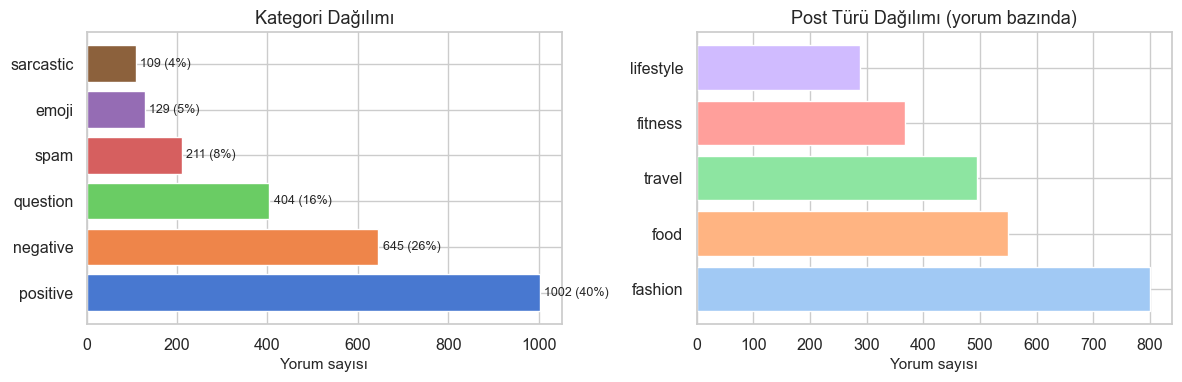

In [80]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

cat_counts = df["mock_category"].value_counts()
axes[0].barh(cat_counts.index, cat_counts.values, color=sns.color_palette("muted", len(cat_counts)))
axes[0].set_title("Kategori Dağılımı")
axes[0].set_xlabel("Yorum sayısı")
for i, v in enumerate(cat_counts.values):
    axes[0].text(v + 10, i, f"{v} ({v/len(df):.0%})", va="center", fontsize=9)

post_counts = df["post_type"].value_counts()
axes[1].barh(post_counts.index, post_counts.values, color=sns.color_palette("pastel", len(post_counts)))
axes[1].set_title("Post Türü Dağılımı (yorum bazında)")
axes[1].set_xlabel("Yorum sayısı")

plt.tight_layout()
plt.show()

## 2. Etkileşim Dağılımları

Like sayıları, post başına yorum yoğunluğu ve yazar aktivitesi incelenir. Sosyal medya etkileşimleri genelde **uzun kuyruklu (long-tail)** dağılır.

In [86]:
likes_stats = df["likes_count"].describe().to_frame("likes_count")
likes_stats = likes_stats.round(0).astype(int)
likes_stats

,likes_count
count,2500
mean,9
std,22
min,0
25%,1
50%,3
75%,5
max,150


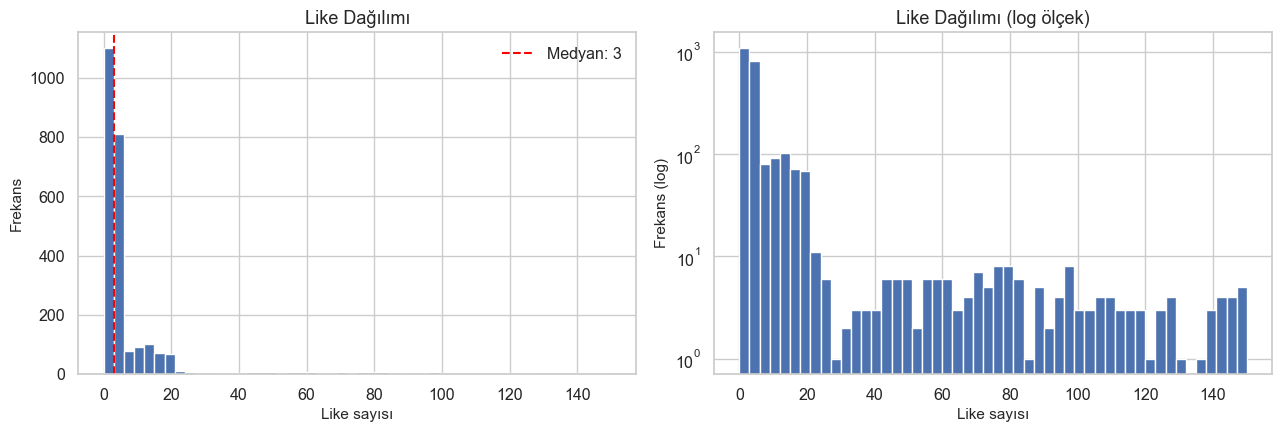

≤5 like alan yorumlar: 76.3%


In [62]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

axes[0].hist(df["likes_count"], bins=50, color="#4C72B0", edgecolor="white")
axes[0].set_title("Like Dağılımı")
axes[0].set_xlabel("Like sayısı")
axes[0].set_ylabel("Frekans")
axes[0].axvline(df["likes_count"].median(), color="red", ls="--", label=f"Medyan: {df['likes_count'].median():.0f}")
axes[0].legend()

axes[1].hist(df["likes_count"], bins=50, color="#4C72B0", edgecolor="white")
axes[1].set_yscale("log")
axes[1].set_title("Like Dağılımı (log ölçek)")
axes[1].set_xlabel("Like sayısı")
axes[1].set_ylabel("Frekans (log)")

plt.tight_layout()
plt.show()

low_like_pct = (df["likes_count"] <= 5).mean()
print(f"≤5 like alan yorumlar: {low_like_pct:.1%}")

In [82]:
likes_by_cat = (
    df.groupby("mock_category", observed=True)["likes_count"]
    .agg(count="count", mean="mean", median="median", max="max")
    .round(1)
    .sort_values("mean", ascending=False)
)
likes_by_cat

,count,mean,median,max
mock_category,,,,
sarcastic,109,12.5,4.0,111
positive,1002,12.0,4.0,149
question,404,11.7,3.0,150
emoji,129,11.1,4.0,143
negative,645,4.3,2.0,80
spam,211,3.9,2.0,78


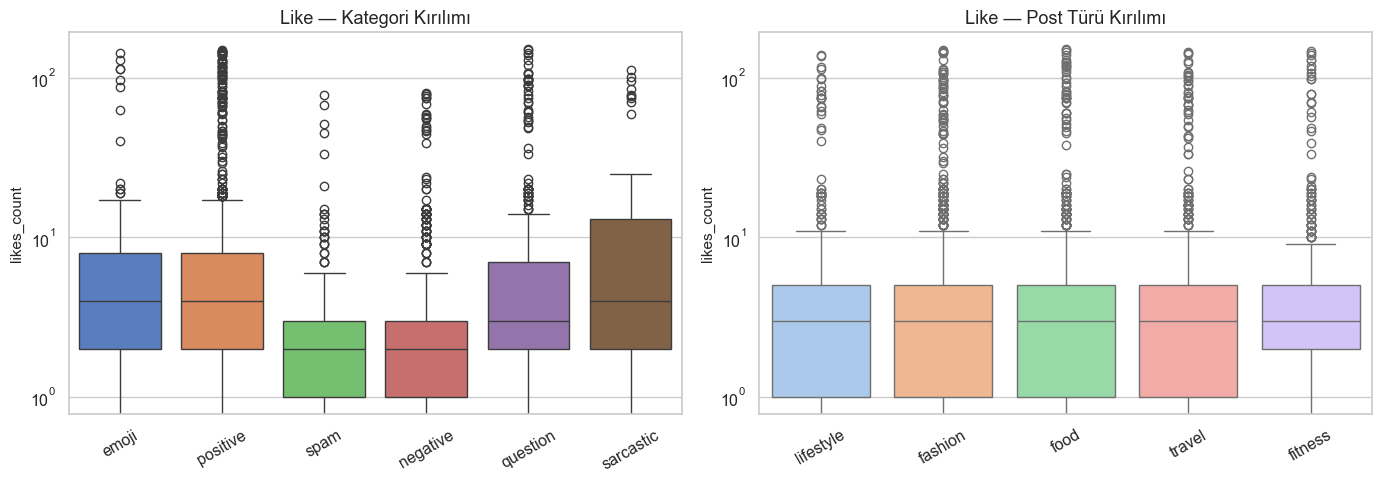

In [88]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.boxplot(data=df, x="mock_category", y="likes_count", ax=axes[0], palette="muted")
axes[0].set_title("Like — Kategori Kırılımı")
axes[0].set_xlabel("")
axes[0].tick_params(axis="x", rotation=30)
axes[0].set_yscale("log")

sns.boxplot(data=df, x="post_type", y="likes_count", ax=axes[1], palette="pastel")
axes[1].set_title("Like — Post Türü Kırılımı")
axes[1].set_xlabel("")
axes[1].tick_params(axis="x", rotation=30)
axes[1].set_yscale("log")

plt.tight_layout()
plt.show()

In [ ]:
comments_per_post = df.groupby("post_id").agg(
    comment_count=("commentId", "count"),
    post_type=("post_type", "first"),
    total_likes=("likes_count", "sum"),
).sort_values("comment_count", ascending=False)

print("Post başına yorum :")
display(comments_per_post["comment_count"].describe().to_frame())
print("\nEn çok yorum alan 5 post:")
display(comments_per_post.head())

Post başına yorum :


,comment_count
count,100.000000
mean,25.000000
std,18.822939
min,16.000000
25%,17.000000
50%,20.000000
75%,26.000000
max,179.000000



En çok yorum alan 5 post:


,comment_count,post_type,total_likes
post_id,,,
99,179,fitness,1366
51,95,travel,1054
83,64,food,638
10,44,fashion,556
34,43,fitness,573


In [68]:
crosstab = pd.crosstab(df["mock_category"], df["post_type"], normalize="index").round(3)
crosstab.style.background_gradient(cmap="YlOrRd", axis=None).format("{:.1%}")

post_type,fashion,fitness,food,lifestyle,travel
mock_category,,,,,
emoji,28.7%,10.1%,19.4%,15.5%,26.4%
negative,32.2%,15.2%,22.2%,10.5%,19.8%
positive,30.2%,15.0%,22.9%,12.3%,19.7%
question,34.2%,16.6%,21.0%,10.6%,17.6%
sarcastic,33.9%,11.9%,30.3%,11.0%,12.8%
spam,36.0%,12.8%,16.1%,10.9%,24.2%


### Değerlendirme

- Like dağılımı **sağa çarpık** (right-skewed) bir dağılıma sahip - sosyal medya etkileşimine uyumlu.
- Kategori bazında 'positive', 'sarcastic' ve 'question' yorumlarının ortalama beğeni sayıları 'negative' ve 'spam' kategorilerine göre daha yüksektir.
- Post türleri arasında belirgin bir etkileşim farkı gözlenmemiştir.
- Post başına yorum ortalaması **25**, max **179**; aşırı tek post yığılması yok.

## 3. Saat / Gün Desenleri

Yorumların hangi saat ve günlerde yoğunlaştığı incelenir. Mock veride zaman damgaları rastgele üretildiğinden **uniform dağılım** beklenir; gerçek veride akşam ve hafta sonu pikleri görülür.

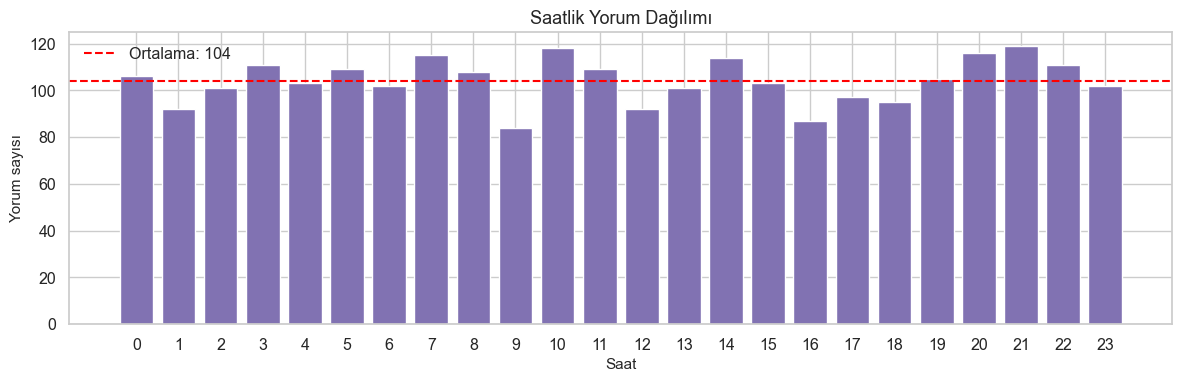

Saatlik dağılım değişim katsayısı (CV): 0.091  (0'a yakın = uniform)


In [69]:
hourly = df.groupby("hour").size()

fig, ax = plt.subplots(figsize=(12, 4))
ax.bar(hourly.index, hourly.values, color="#8172B2", edgecolor="white")
ax.set_title("Saatlik Yorum Dağılımı")
ax.set_xlabel("Saat")
ax.set_ylabel("Yorum sayısı")
ax.set_xticks(range(0, 24))
ax.axhline(hourly.mean(), color="red", ls="--", label=f"Ortalama: {hourly.mean():.0f}")
ax.legend()
plt.tight_layout()
plt.show()

hourly_cv = hourly.std() / hourly.mean()
print(f"Saatlik dağılım değişim katsayısı (CV): {hourly_cv:.3f}  (0'a yakın = uniform)")

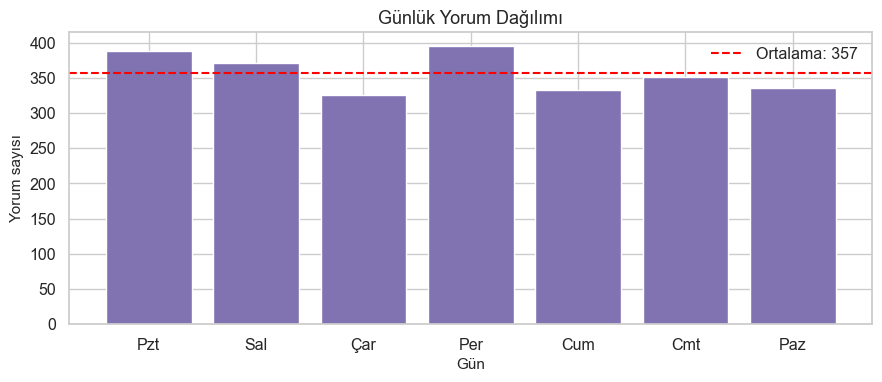

In [70]:
daily = df.groupby("day_of_week", observed=True).size()
daily_labels = [DAY_LABELS_TR[d] for d in daily.index]

fig, ax = plt.subplots(figsize=(9, 4))
ax.bar(daily_labels, daily.values, color="#8172B2", edgecolor="white")
ax.set_title("Günlük Yorum Dağılımı")
ax.set_xlabel("Gün")
ax.set_ylabel("Yorum sayısı")
ax.axhline(daily.mean(), color="red", ls="--", label=f"Ortalama: {daily.mean():.0f}")
ax.legend()
plt.tight_layout()
plt.show()

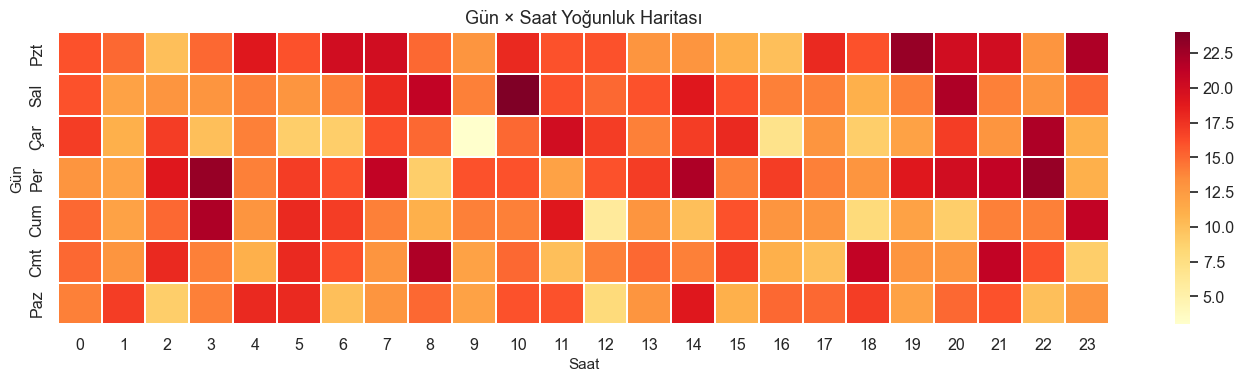

In [71]:
heatmap_data = df.pivot_table(
    index="day_of_week", columns="hour", aggfunc="size", fill_value=0, observed=True
)
heatmap_data.index = [DAY_LABELS_TR[d] for d in heatmap_data.index]

fig, ax = plt.subplots(figsize=(14, 4))
sns.heatmap(heatmap_data, cmap="YlOrRd", annot=False, linewidths=0.3, ax=ax)
ax.set_title("Gün × Saat Yoğunluk Haritası")
ax.set_xlabel("Saat")
ax.set_ylabel("Gün")
plt.tight_layout()
plt.show()

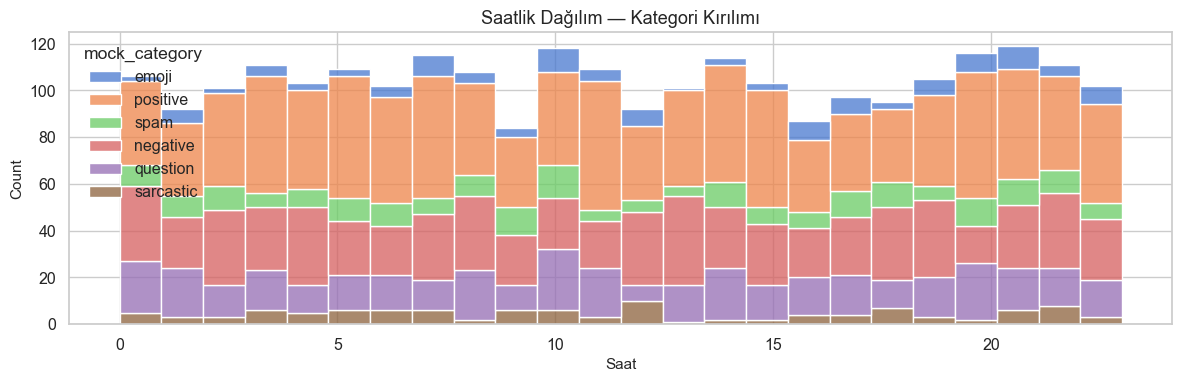

In [ ]:
fig, ax = plt.subplots(figsize=(12, 4))
sns.histplot(data=df, x="hour", hue="mock_category", multiple="stack", bins=24, ax=ax, palette="muted")
ax.set_title("Saatlik Dağılım — Kategori Dağılımı")
ax.set_xlabel("Saat")
plt.tight_layout()
plt.show()

### Değerlendirme

- Saatlik dağılım neredeyse düz (uniform). Mock üreticide rastgele zaman ataması nedeniyle beklenen davranış.
- Günlük dağılım da benzer şekilde düzgün; hafta sonu veya akşam piki yok.
- Gün × saat heatmap’te belirgin yoğun bölge görünmüyor — gerçek Instagram trafiğindeki “akşam / Cuma–Pazar” desenini yansıtmıyor.

## 4. Yorum Uzunlukları

Karakter ve kelime sayısı üzerinden yorum uzunluğu dağılımları; kategori ve post türü dağılımları.

In [74]:
length_stats = df[["text_length", "word_count"]].describe().round(1)
length_stats

,text_length,word_count
count,2500.0,2500.0
mean,38.6,5.6
std,14.7,1.8
min,1.0,1.0
25%,30.0,5.0
50%,40.0,6.0
75%,49.0,7.0
max,82.0,11.0


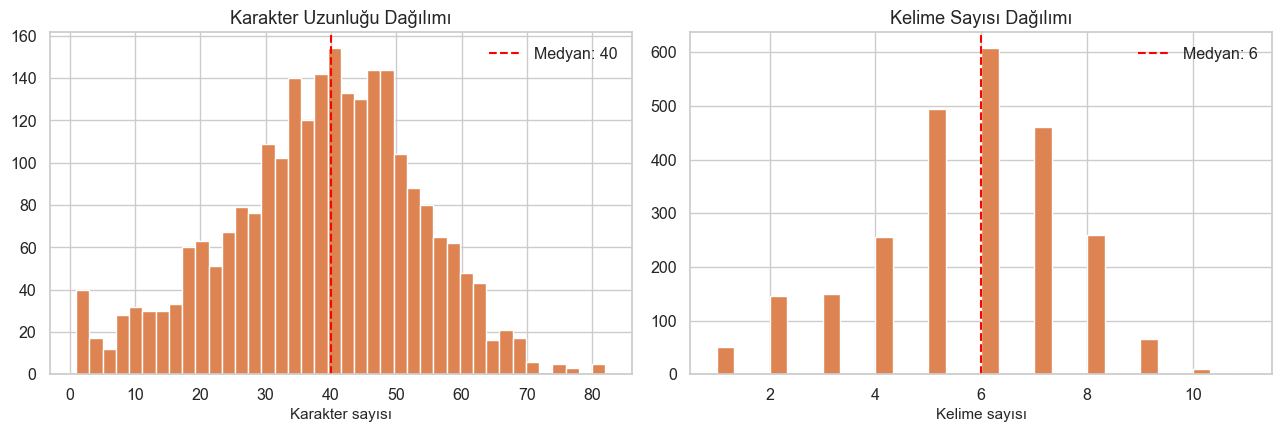

In [75]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

axes[0].hist(df["text_length"], bins=40, color="#DD8452", edgecolor="white")
axes[0].set_title("Karakter Uzunluğu Dağılımı")
axes[0].set_xlabel("Karakter sayısı")
axes[0].axvline(df["text_length"].median(), color="red", ls="--", label=f"Medyan: {df['text_length'].median():.0f}")
axes[0].legend()

axes[1].hist(df["word_count"], bins=30, color="#DD8452", edgecolor="white")
axes[1].set_title("Kelime Sayısı Dağılımı")
axes[1].set_xlabel("Kelime sayısı")
axes[1].axvline(df["word_count"].median(), color="red", ls="--", label=f"Medyan: {df['word_count'].median():.0f}")
axes[1].legend()

plt.tight_layout()
plt.show()

In [76]:
length_by_cat = (
    df.groupby("mock_category", observed=True)[["text_length", "word_count"]]
    .agg(["mean", "median", "min", "max"])
    .round(1)
)
length_by_cat

text_length                word_count               
                     mean median min max       mean median min max
mock_category                                                     
emoji                 8.8    8.0   1  29        1.9    2.0   1   3
negative             45.9   48.0   6  82        6.5    7.0   1  11
positive             37.5   38.0   1  71        5.5    6.0   1   9
question             38.3   39.0  17  67        5.3    5.0   3   8
sarcastic            36.9   35.0  19  75        5.8    5.0   3   9
spam                 41.0   42.0  18  68        5.8    6.0   3   9

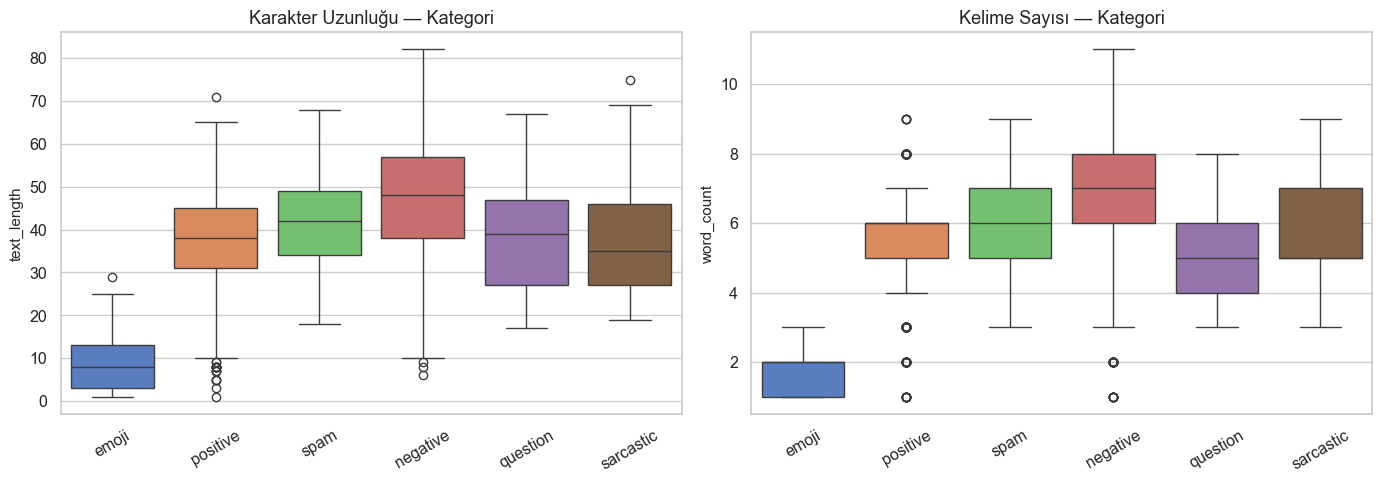

In [77]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.boxplot(data=df, x="mock_category", y="text_length", ax=axes[0], palette="muted")
axes[0].set_title("Karakter Uzunluğu — Kategori")
axes[0].set_xlabel("")
axes[0].tick_params(axis="x", rotation=30)

sns.boxplot(data=df, x="mock_category", y="word_count", ax=axes[1], palette="muted")
axes[1].set_title("Kelime Sayısı — Kategori")
axes[1].set_xlabel("")
axes[1].tick_params(axis="x", rotation=30)

plt.tight_layout()
plt.show()

In [78]:
print("En kısa 5 yorum:")
display(df.nsmallest(5, "text_length")[["text", "mock_category", "text_length"]])

print("\nEn uzun 5 yorum:")
display(df.nlargest(5, "text_length")[["text", "mock_category", "text_length"]])

En kısa 5 yorum:


,text,mock_category,text_length
441,🙄,emoji,1
596,💯,emoji,1
610,👎,emoji,1
682,😍,emoji,1
857,👎,emoji,1



En uzun 5 yorum:


,text,mock_category,text_length
72,"sürekli aynı tarz, outfitlarınız artık sıkıcıl...",negative,82
2372,"sürekli aynı tarz, kombinlarınız artık sıkıcıl...",negative,82
16,"Sürekli aynı tarz, antrenmanlarınız artık sıkı...",negative,80
2146,Sadece izlenme almak için yapılmış abartılı bi...,negative,80
2386,dm'lere neden cevap vermiyorsunuz? i̇lgisizlik...,negative,80


### Değerlendirme

- Ortalama **~39 karakter / ~5.6 kelime**; Kısa sosyal medya yorum profiline yakın.
- Kategori ayrımı net: emoji en kısa (~9 karakter), negative en uzun (~46), positive/question/spam orta bantta.
- Uç değerler anlamlı: tek emoji/kısa tepki ile ~80 karaktere çıkan şablon cümleler bir arada — gerçek yorum çeşitliliğini kısmen yakalıyor.

# 6. Bulgular Özeti

**Veri:** `mock_comments.json` · **N = 2.500** yorum · **100 post** · **10 hesap** · **300 yazar**

**İncelenen Alanlar:** Etkileşim dağılımları, zamansal desenler, yorum uzunlukları ve veri tutarlılığı.

## Özet Tablo

| Alan | Bulgu |
|------|--------|
| Like dağılımı | Medyan 3, yorumların büyük bölümü ≤5 like, right-skewed dağılım |
| Kategori × Like | `positive`, `sarcastic` ve `question` kategorileri daha yüksek etkileşim göstermektedir |
| Post etkileşimi | Gönderi başına ortalama 25 yorum, maksimum 179 yorum |
| Hesap – Post ilişkisi | Her gönderi tek bir hesaba bağlı olacak şekilde tutarlı yapıdadır |
| Saat / Gün dağılımı | Belirgin yoğunluk veya trafik piki gözlenmemektedir |
| Yorum uzunluğu | Kısa yorumlar baskındır; **negative** yorumları en uzun, **emoji** yorumları ise en kısa metinlere sahiptir |
| Veri tutarlılığı | Yinelenen kayıt ve veri bütünlüğü açısından önemli bir sorun gözlenmemiştir |

## Ana Bulgular

1. **Etkileşim dağılımı sağa çarpık bir yapı sergilemektedir.** Yorumların büyük bölümü düşük sayıda beğeni alırken, az sayıdaki yüksek etkileşimli yorum dağılımın sağ kuyruğunu oluşturmaktadır. Bu yapı sosyal medya etkileşimlerinde yaygın olarak gözlenen uzun kuyruklu dağılımla uyumludur.

2. **Kategori bazında etkileşim farklılıkları gözlenmiştir.** `positive`, `sarcastic` ve `question` kategorilerindeki yorumlar, `negative` ve `spam` kategorilerine göre daha yüksek beğeni değerlerine sahiptir. Post türü, like sayısını kategori kadar belirgin şekilde ayırmıyor.

3. **Zamansal dağılımlar belirgin bir yoğunlaşma göstermemektedir.** Saat ve gün bazındaki yorum dağılımları incelenmiş, belirli zaman aralıklarında dikkat çekici bir trafik yoğunluğu gözlenmemiştir. Bu nedenle zaman değişkenlerinin yorum davranışı üzerindeki etkisi sınırlı görünmektedir.

4. **Yorum uzunlukları incelendiğinde kısa yorumların veri setinde baskın olduğu görülmektedir.** Kategori bazında değerlendirildiğinde **negative** yorumları en yüksek karakter ve kelime uzunluğuna sahipken, **emoji** yorumları en kısa metinlerden oluşmaktadır. Bu durum, farklı yorum türlerinin doğal yazım biçimlerini yansıtmakta ve veri setine metinsel çeşitlilik kazandırmaktadır.

5. **Veri yapısı tutarlı ve analiz için uygundur.** Hesap–gönderi ilişkileri, yazar bilgileri ve metin alanları arasında önemli bir tutarsızlık tespit edilmemiştir. Genel veri kalitesi, sonraki analiz ve modelleme adımları için yeterli düzeydedir.

## İyileştirme Önerileri

1. Saat ve gün dağılımlarına daha gerçekçi kullanım yoğunlukları eklenebilir.
2. Uzun ve açıklayıcı yorumların oranı artırılarak metin çeşitliliği geliştirilebilir.
3. Farklı kullanıcı davranışlarını temsil edecek ek etkileşim senaryoları oluşturulabilir.
4. Elde edilen veri seti, sonraki model geliştirme ve değerlendirme aşamalarında temel veri kaynağı olarak kullanılabilir.

---
*Notebook: `01.eda.ipynb` | Veri: `src/mock_comments.json`*